In [1]:
print("Nusrat Anjum")

Nusrat Anjum


In [2]:
import pandas as pd
df = pd.read_csv("zomato.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      7214 non-null   object
 1   name                         7214 non-null   object
 2   online_order                 7213 non-null   object
 3   book_table                   7210 non-null   object
 4   rate                         6292 non-null   object
 5   votes                        7210 non-null   object
 6   phone                        7078 non-null   object
 7   location                     7205 non-null   object
 8   rest_type                    7180 non-null   object
 9   dish_liked                   3475 non-null   object
 10  cuisines                     7201 non-null   object
 11  approx_cost(for two people)  7191 non-null   object
 12  listed_in(type)              6768 non-null   object
dtypes: object(13)
memory usage: 732.8

In [4]:
df.isnull().sum()

,0
address,0
name,0
online_order,1
book_table,4
rate,922
votes,4
phone,136
location,9
rest_type,34
dish_liked,3739


In [5]:
df.duplicated().sum()

np.int64(610)

In [6]:
df=df.drop_duplicates()
print("New Shape:",df.shape)

New Shape: (6604, 13)


In [7]:
df=df.dropna()
print("New Shape after removing missing values:",df.shape)

New Shape after removing missing values: (2788, 13)


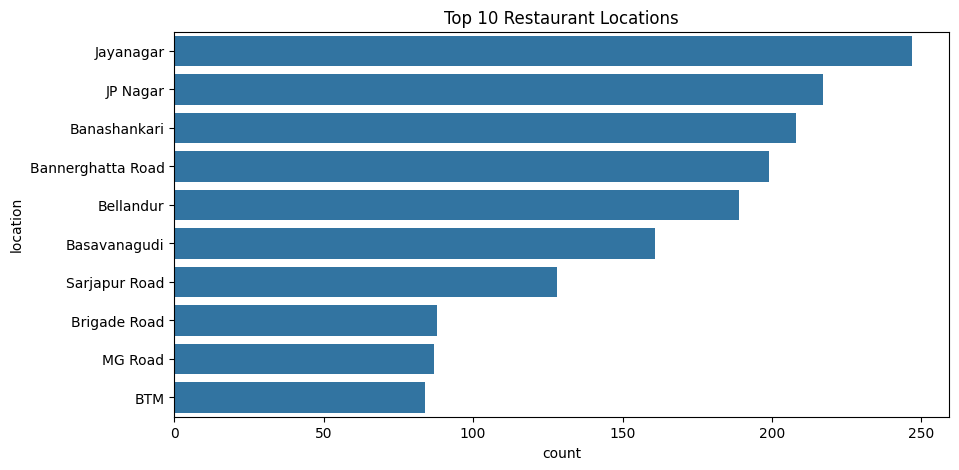

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(y=df['location'],
              order=df['location'].value_counts().head(10).index)
plt.title("Top 10 Restaurant Locations")
plt.show()

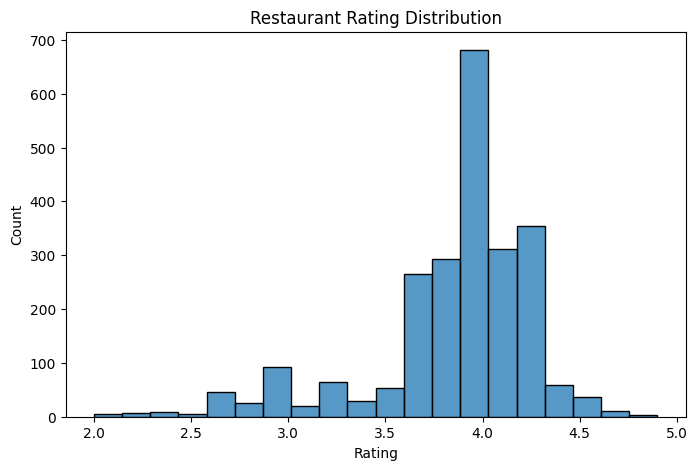

In [10]:
#Convert rating column to numeric
df['rate']=df['rate'].str.replace('/5','',regex=False)
df['rate']=pd.to_numeric(df['rate'],errors='coerce')

plt.figure(figsize=(8,5))
sns.histplot(df['rate'],bins=20)

plt.title("Restaurant Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

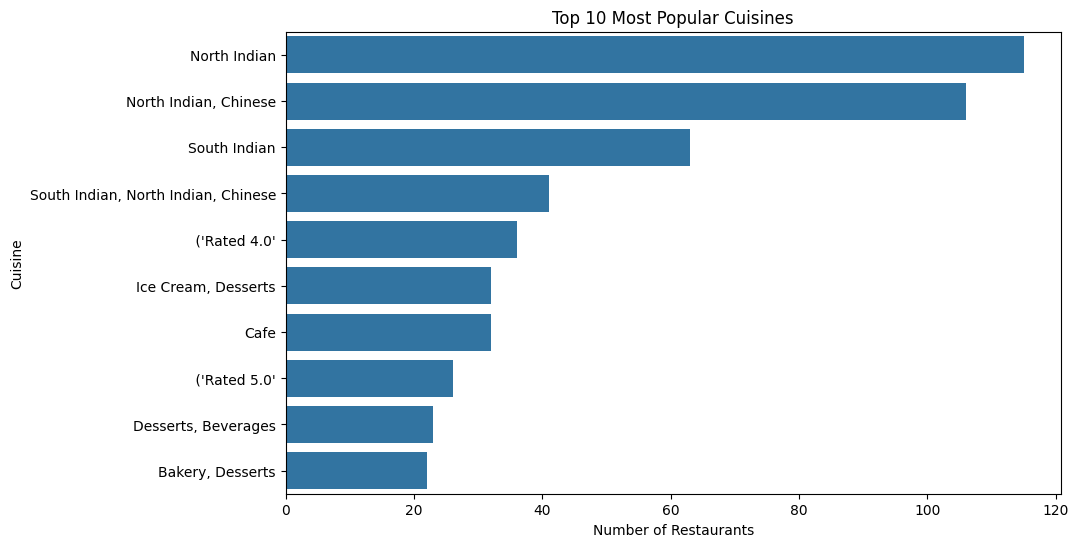

In [11]:
plt.figure(figsize=(10,6))

top_cuisines = df['cuisines'].value_counts().head(10)

sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.show()

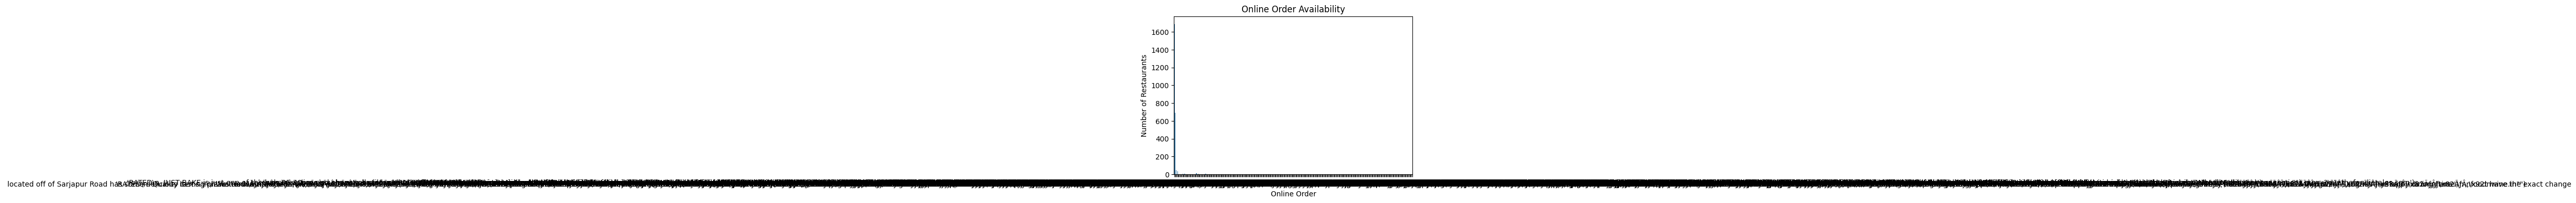

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['online_order'])

plt.title("Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")

plt.show()


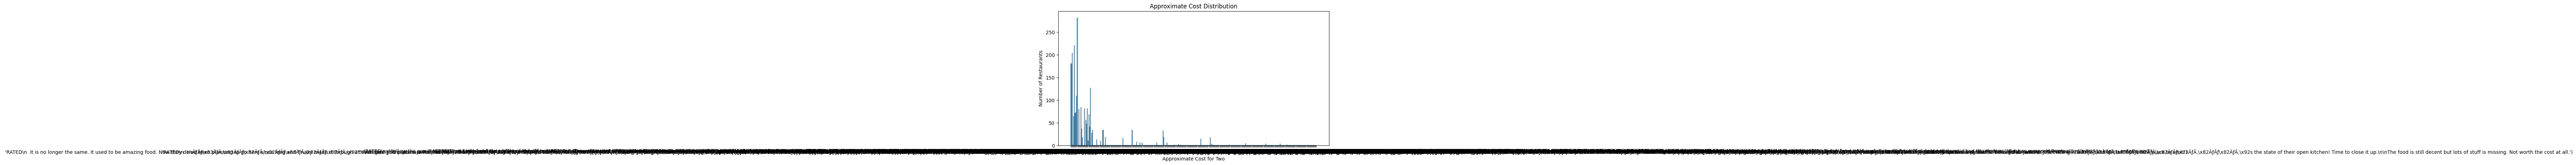

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['approx_cost(for two people)'], bins=30)

plt.title("Approximate Cost Distribution")
plt.xlabel("Approximate Cost for Two")
plt.ylabel("Number of Restaurants")

plt.show()

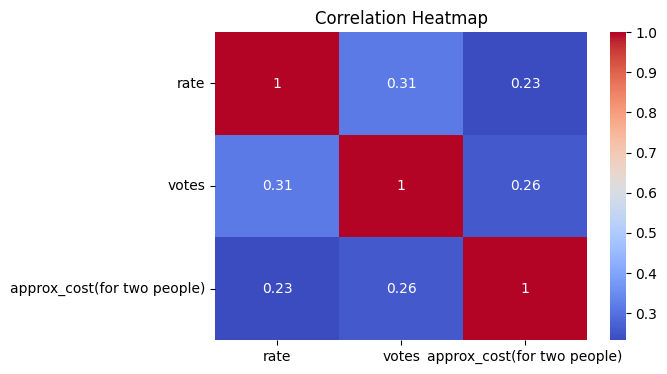

In [17]:
# Convert columns to numeric

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    df[['rate','votes','approx_cost(for two people)']].corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
df.to_csv("zomato_cleaned.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
